# Sales Analysis: City with Highest Sales

## Question 2: What city sold the most product?

This analysis determines which city had the highest quantity of products sold.

**Dataset:** Sales_Data_Cleaned.csv

## Step 1: Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the sales data
all_data = pd.read_csv("../dataset/Sales_Data_Cleaned.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


## Step 2: Extract City Information from Address

In [2]:
# Define functions to extract city and state from purchase address
def get_city(address):
    # Split address by comma and get the city (second element)
    return address.split(",")[1].strip()

def get_state(address):
    # Split address to extract state abbreviation
    return address.split(",")[2].split(" ")[1]

# Apply functions to create a new 'City' column with city and state
all_data["City"] = all_data["Purchase Address"].apply(lambda x: f"{get_city(x)} ({get_state(x)})")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",New York City (NY)
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",New York City (NY)
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",New York City (NY)
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",San Francisco (CA)
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",Atlanta (GA)


## Step 3: Analyze Sales by City

In [3]:
# Group by city and calculate total quantity ordered
city_sales = all_data.groupby("City")['Quantity Ordered'].sum()
print("Total Quantity Ordered by City:")
print(city_sales.sort_values(ascending=False))

Total Quantity Ordered by City:
City
San Francisco (CA)    50239
Los Angeles (CA)      33289
New York City (NY)    27932
Boston (MA)           22528
Dallas (TX)           16730
Atlanta (GA)          16602
Seattle (WA)          16553
Portland (OR)         11303
Austin (TX)           11153
Portland (ME)          2750
Name: Quantity Ordered, dtype: int64


## Step 4: Visualize City Sales

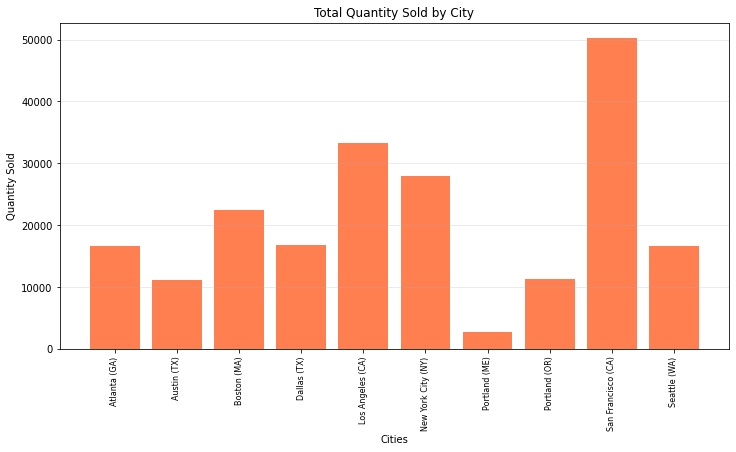


=== CONCLUSION ===
City with Highest Sales: San Francisco (CA) with 50,239 units sold


In [4]:
# Prepare data for plotting
cities = [city for city, df in all_data.groupby('City')]

# Create bar chart showing quantities sold by each city
plt.figure(figsize=(12, 6))
plt.bar(cities, all_data.groupby("City")['Quantity Ordered'].sum(), color='coral')

plt.ylabel('Quantity Sold')
plt.xlabel('Cities')
plt.xticks(cities, rotation='vertical', size=8)
plt.title('Total Quantity Sold by City')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Find the city with highest sales
top_city = city_sales.idxmax()
top_quantity = city_sales.max()
print(f"\n=== CONCLUSION ===")
print(f"City with Highest Sales: {top_city} with {top_quantity:,} units sold")

## Conclusion

**Answer:** The city with the highest quantity of products sold is San Francisco (CA).
